# 📊 Previsão de churn em academia com machine learning

## 🎯 Contexto do problema
A evasão de alunos (churn) é um dos principais desafios enfrentados por academias, impactando diretamente a receita e a sustentabilidade do negócio. Compreender os fatores que levam um aluno a cancelar sua matrícula é essencial para a criação de estratégias de retenção.

## 🎯 Objetivo do projeto
Desenvolver um modelo de Machine Learning capaz de prever quais alunos possuem maior probabilidade de evasão, utilizando variáveis comportamentais e contratuais, como:

- Frequência semanal de treinos  
- Valor da mensalidade  
- Tipo de plano (mensal, trimestral, anual)  
- Uso de personal trainer  
- Sexo do aluno  

Além da previsão, o projeto busca estimar o impacto financeiro do churn e simular cenários de redução da evasão, auxiliando na tomada de decisão estratégica da academia.

In [1]:
# importar as bibliotecas necessárias

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Carregar os dados e realizar a limpeza necessária

def load_data():
    df = pd.read_excel('dataset_academia.xlsx')

    # Limpeza segura do churn
    df['churn'] = (
        df['churn']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'sim': 1, 'não': 0, 'nao': 0})
    )

    # Limpeza do personal
    df['personal'] = (
        df['personal']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'sim': 1, 'não': 0, 'nao': 0})
    )

    # Remover linhas inválidas
    df = df.dropna(subset=['churn', 'plano'])

    return df

# Sempre começa daqui
df = load_data()

## 📊 Análise exploratória dos dados

Nesta etapa, exploramos os dados para identificar padrões e relações entre as variáveis e o churn.

### 🔎 Perguntas analisadas:
- Qual plano tem maior evasão?
- Existe relação entre frequência e churn?
- O uso de personal influencia na retenção?
- Existe diferença entre homens e mulheres?

In [3]:
# Funções para gráficos de análise exploratória

# função para plotar churn por plano
def plot_churn_plano(df):
    plt.figure(figsize=(6, 4))
    (df.groupby('plano')['churn']
       .mean()
       .mul(100)
       .plot(kind='bar'))
    plt.title('Churn por Plano')
    plt.ylabel('%')
    plt.show()
    plt.close()

# Função para plotar churn por sexo
def plot_churn_sexo(df):
    plt.figure(figsize=(6, 4))
    (df.groupby('sexo')['churn']
       .mean()
       .mul(100)
       .plot(kind='bar'))
    plt.title('Churn por Sexo')
    plt.ylabel('%')
    plt.show()
    plt.close()

# Função para plotar churn por frequência semanal
def plot_churn_frequencia(df):
    plt.figure(figsize=(6, 4))
    (df.groupby('frequencia_semanal')['churn']
       .mean()
       .mul(100)
       .plot(kind='bar'))
    plt.title('Churn por Frequência')
    plt.ylabel('%')
    plt.show()
    plt.close()

(0.0, 59.056603773584904)

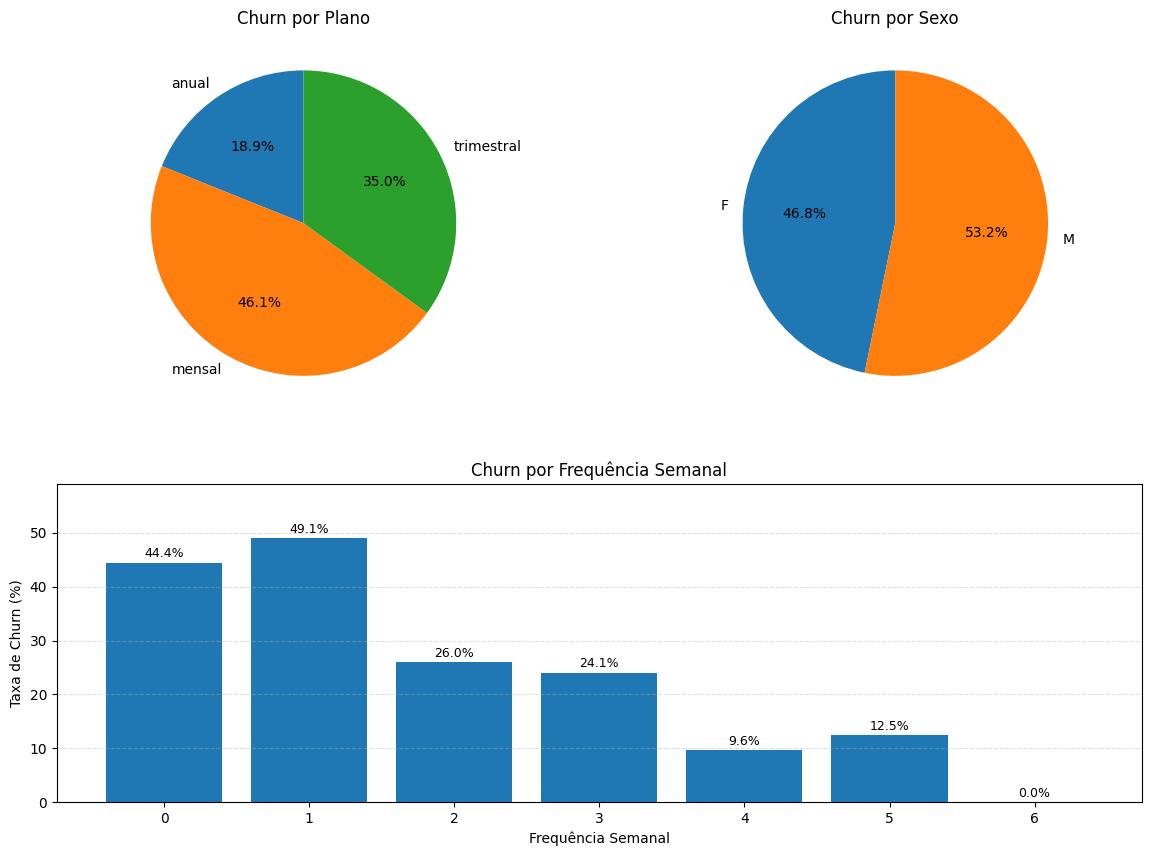

In [4]:
# Graficos de análise exploratória

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])  # pizzas maiores

# Pizza com churn por plano
ax1 = fig.add_subplot(gs[0, 0])
(df.groupby('plano')['churn']
   .mean()
   .mul(100)
   .plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=ax1))
ax1.set_title('Churn por Plano')
ax1.set_ylabel('')

# Pizza com churn por sexo
ax2 = fig.add_subplot(gs[0, 1])
(df.groupby('sexo')['churn']
   .mean()
   .mul(100)
   .plot(kind='pie', autopct='%1.1f%%', startangle=90, ax=ax2))
ax2.set_title('Churn por Sexo')
ax2.set_ylabel('')

# Barra com churn por frequência semanal
ax3 = fig.add_subplot(gs[1, :])

freq = (df.groupby('frequencia_semanal')['churn']
          .mean()
          .mul(100)
          .sort_index())  # mantém ordem lógica (1x, 2x, 3x...)

bars = ax3.bar(freq.index.astype(str), freq.values)

ax3.set_title('Churn por Frequência Semanal', fontsize=12)
ax3.set_ylabel('Taxa de Churn (%)')
ax3.set_xlabel('Frequência Semanal')

# valores em cima das barras
for i, v in enumerate(freq.values):
    ax3.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)

# grid leve
ax3.grid(axis='y', linestyle='--', alpha=0.4)

# melhorar espaçamento
ax3.set_ylim(0, freq.max() + 10)

## 💡 Principais insights

- Alunos com menor frequência semanal apresentam maior risco de churn.
- Planos mensais tendem a ter maior evasão em comparação com planos mais longos.
- Clientes sem personal trainer possuem maior probabilidade de saída.
- A retenção está diretamente ligada ao engajamento do aluno.

## ⚙️ Preparação dos dados

Para o treinamento do modelo, foram realizadas as seguintes etapas:

- Conversão de variáveis categóricas em numéricas (get_dummies)
- Tratamento da variável churn (0 e 1)
- Remoção de colunas irrelevantes (nome, id)
- Separação entre variáveis de entrada (X) e variável alvo (y)

In [5]:
# Transformar variáveis categóricas em dummies

df_model = pd.get_dummies(df, columns=['plano', 'sexo', 'nome'], drop_first=True)

# Preparação dos dados para modelagem
# Remover colunas irrelevantes e definir X e y
# X (features) → dados de entrada
# y (target) → variável que queremos prever (churn)

X = df_model.drop(['id_aluno', 'churn'], axis=1)
y = df_model['churn']

In [6]:
# Dividir os dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Treinar o modelo de Random Forest
# n_estimators → número de árvores na floresta
# random_state → para garantir reprodutibilidade
# fit → treina o modelo com os dados de treino

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 📈 Avaliação do modelo

O modelo foi avaliado utilizando as seguintes métricas:

- Acurácia
- Precision
- Recall
- F1-score

Essas métricas ajudam a entender a capacidade do modelo em identificar corretamente os alunos com risco de evasão.

In [7]:
# Avaliar o modelo no conjunto de teste

y_pred = model.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia: 0.7166666666666667
              precision    recall  f1-score   support

           0       0.72      0.98      0.83        43
           1       0.50      0.06      0.11        17

    accuracy                           0.72        60
   macro avg       0.61      0.52      0.47        60
weighted avg       0.66      0.72      0.63        60



## 💰 Impacto financeiro do Churn

A evasão de alunos impacta diretamente a receita da academia.

Nesta etapa, foi calculado:
- Receita total
- Receita perdida com churn
- Percentual de impacto financeiro

In [8]:
# Análise de impacto financeiro do churn

receita_total = df['mensalidade'].sum()

clientes_churn = df['churn'] == 1
receita_perdida = df.loc[clientes_churn, 'mensalidade'].sum()

impacto = receita_perdida / receita_total

print(f"Churn atual: {df['churn'].mean():.2%}")
print(f"Impacto na receita: {impacto:.2%}")

Churn atual: 27.67%
Impacto na receita: 24.60%


## 📉 Simulação de redução de churn

Foi realizada uma simulação considerando a redução de churn em 20%.

### 🎯 Resultado:
- Redução significativa na perda de receita
- Demonstra o valor estratégico de ações de retenção

In [9]:
# Simular redução de churn em 20% e calcular novo impacto

reducao = 0.2

nova_perda = receita_perdida * (1 - reducao)
novo_impacto = nova_perda / receita_total

print(f"Impacto com redução de churn: {novo_impacto:.2%}")

Impacto com redução de churn: 19.68%


## 🚨 Identificação de alunos com alto risco de churn

A partir do modelo treinado, foi possível identificar os alunos com maior probabilidade de evasão.

Esses dados podem ser utilizados para ações estratégicas de retenção, como:
- Ofertas personalizadas
- Contato ativo
- Incentivo ao uso de personal trainer

In [10]:
# Garantir que está sendo usando os dados de teste
df_result = X_test.copy().reset_index()

# Probabilidade de churn (classe 1)
df_result['Prob_Churn'] = model.predict_proba(X_test)[:, 1]

# Adicionar identificação do aluno (do df original)
df_result['id_aluno'] = df.loc[df_result['index'], 'id_aluno'].values

# (Opcional) adicionar algumas infos importantes
df_result['nome'] = df.loc[df_result['index'], 'nome'].values
df_result['plano'] = df.loc[df_result['index'], 'plano'].values
df_result['frequencia'] = df.loc[df_result['index'], 'frequencia_semanal'].values
df_result['personal'] = df.loc[df_result['index'], 'personal'].values
df_result['mensalidade'] = df.loc[df_result['index'], 'mensalidade'].values

# Top 10 maior risco
top10 = df_result.sort_values('Prob_Churn', ascending=False).head(10)

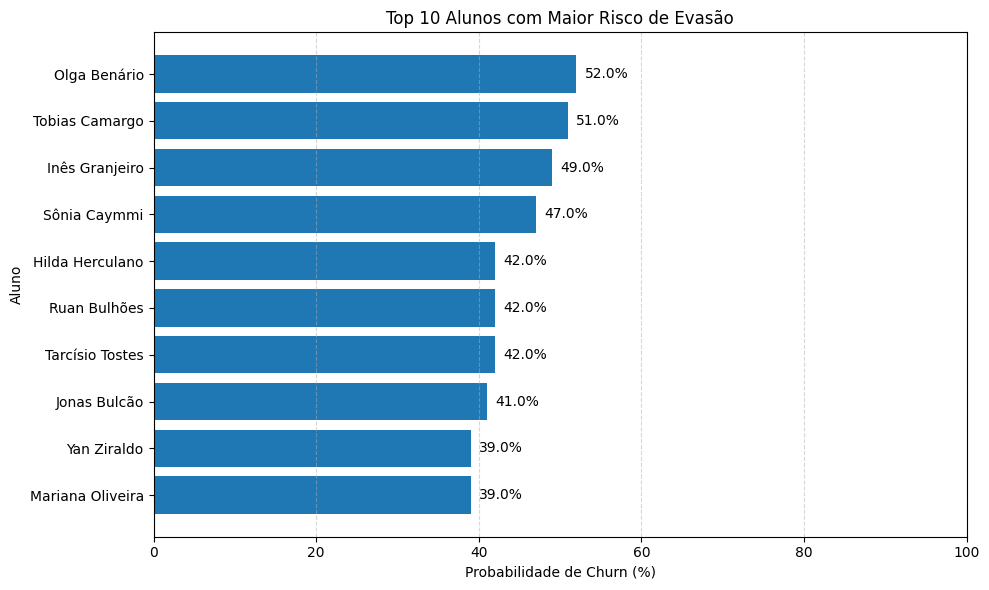

In [11]:
# Visualização do top 10 alunos com maior risco de churn
plt.figure(figsize=(10, 6))

# ordenar (garante visual correto)
top10 = top10.sort_values('Prob_Churn', ascending=True)

bars = plt.barh(
    top10['nome'],
    top10['Prob_Churn'] * 100
)

# adicionar valores nas barras
for i, v in enumerate(top10['Prob_Churn'] * 100):
    plt.text(v + 1, i, f"{v:.1f}%", va='center')

plt.xlabel('Probabilidade de Churn (%)')
plt.ylabel('Aluno')
plt.title('Top 10 Alunos com Maior Risco de Evasão')

plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()

## 🧠 Conclusão

O modelo desenvolvido demonstrou capacidade de identificar padrões de evasão de alunos.

A análise evidenciou que fatores como frequência e engajamento são determinantes para retenção.

Com base nesses insights, a academia pode adotar estratégias mais assertivas para reduzir churn e aumentar a receita.